## Welcome to Week 4, Day 4

This is the start of an AWESOME project! Really simple and very effective.

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain.agents import Tool

from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver

In [2]:
load_dotenv(override=True)

True

### Asynchronous LangGraph

To run a tool:  
Sync: `tool.run(inputs)`  
Async: `await tool.arun(inputs)`

To invoke the graph:  
Sync: `graph.invoke(state)`  
Async: `await graph.ainvoke(state)`

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [4]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = 'https://api.pusover.net/2/messages.json'

def push(text: str):
    '''Send a push notification to the user'''
    requests.post(pushover_url, data = {'token': pushover_token, 'user': pushover_user, 'message': text})

tool_push = Tool(
    name='send_push_notification',
    func=push,
    description='useful for when you want to send a push notification'
)

## Extra installation step - if you don't have Node and Playwright on your computer

Next, you need to install NodeJS and Playwright on your computer if you don't already have them. Please see instructions here:

[Node and Playwright setup](../setup/SETUP-node.md)

## And now - after Installing Playwright, a heads up for Windows PC Users:

While executing the next few cells, you might hit a problem with the Playwright browser raising a NotImplementedError.

This should work when we move to python modules, but it can cause problems in Windows in a notebook.

If you it this error and would like to run the notebook, you need to make a small change which seems quite hacky! You need to do this AFTER installing Playwright (prior cells)

1. Right click in `.venv` in the File Explorer on the left and select "Find in folder"
2. Search for `asyncio.set_event_loop_policy(WindowsSelectorEventLoopPolicy())`  
3. That code should be found in a line of code in a file called `kernelapp.py`
4. Comment out the entire else clause that this line is a part of - see the fragment below. Be sure to have the "pass" statement after the ImportError line.
5. Restart the kernel by pressing the "Restart" button above

```python
        if sys.platform.startswith("win") and sys.version_info >= (3, 8):
            import asyncio
 
            try:
                from asyncio import WindowsProactorEventLoopPolicy, WindowsSelectorEventLoopPolicy
            except ImportError:
                pass
                # not affected
           # else:
            #    if type(asyncio.get_event_loop_policy()) is WindowsProactorEventLoopPolicy:
                    # WindowsProactorEventLoopPolicy is not compatible with tornado 6
                    # fallback to the pre-3.8 default of Selector
                    # asyncio.set_event_loop_policy(WindowsSelectorEventLoopPolicy())
```

Thank you to student Nicolas for finding this, and to Kalyan, Yaki, Zibin and Bhaskar for confirming that this worked for them! And to Vladislav for the extra pointers.

As an alternative, you can just move to a Python module (which we do anyway in Day 5)

In [5]:
# Introducing nest_asyncio
# Python async code only allows for one "event loop" processing aynchronous events.
# The `nest_asyncio` library patches this, and is used for special situations, if you need to run a nested event loop.

import os
# Prevent uvicorn from using uvloop (which causes issues in threads)
os.environ['UVICORN_LOOP'] = 'asyncio'

import nest_asyncio
import asyncio

# Apply nest_asyncio first
nest_asyncio.apply()

# Force default asyncio event loop policy to avoid uvloop conflicts with Gradio
# uvloop doesn't work well in threads, which Gradio uses for uvicorn
asyncio.set_event_loop_policy(asyncio.DefaultEventLoopPolicy())

### The LangChain community

One of the remarkable things about LangChain is the rich community around it.

Check this out:


In [6]:
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser

async_browser = create_async_playwright_browser(headless=False) # headful node
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()

In [7]:
for tool in tools:
    print(f"{tool.name}={tool}")

click_element=async_browser=<Browser type=<BrowserType name=chromium executable_path=/Users/samarthrao/Library/Caches/ms-playwright/chromium-1169/chrome-mac/Chromium.app/Contents/MacOS/Chromium> version=136.0.7103.25>
navigate_browser=async_browser=<Browser type=<BrowserType name=chromium executable_path=/Users/samarthrao/Library/Caches/ms-playwright/chromium-1169/chrome-mac/Chromium.app/Contents/MacOS/Chromium> version=136.0.7103.25>
previous_webpage=async_browser=<Browser type=<BrowserType name=chromium executable_path=/Users/samarthrao/Library/Caches/ms-playwright/chromium-1169/chrome-mac/Chromium.app/Contents/MacOS/Chromium> version=136.0.7103.25>
extract_text=async_browser=<Browser type=<BrowserType name=chromium executable_path=/Users/samarthrao/Library/Caches/ms-playwright/chromium-1169/chrome-mac/Chromium.app/Contents/MacOS/Chromium> version=136.0.7103.25>
extract_hyperlinks=async_browser=<Browser type=<BrowserType name=chromium executable_path=/Users/samarthrao/Library/Caches/

In [10]:
tool_dict = {tool.name:tool for tool in tools}

navigate_tool = tool_dict.get('navigate_browser')
extract_text_tool = tool_dict.get('extract_text')

await navigate_tool.arun({'url': 'https://news.google.com/'})
text = await extract_text_tool.arun({})

In [11]:
import textwrap
print(textwrap.fill(text))

Google News News Google News News Advanced search Narrow your search
results Exact phrase Has words Exclude words Website Enter a valid web
address Date Any time Any time Past hour Past 24 hours Past week Past
year Clear Search Help Help Privacy Terms About Google Get the Android
app Get the iOS app Send feedback Settings Settings Language & region
English (India) Sign in Home For you Following News Showcase India
World Local Business Technology Entertainment Sports Science Health
More Your briefing Sunday 28 December Today 26° 16° Mon 26° 16° Tue
27° 17° Wed 28° 18° Bengaluru 24°C Google Weather Top stories Hindu
man lynched in Bangladesh chevron_right Times of India More Watch:
Khalistanis in UK disrupt protest by Hindus over killings in
Bangladesh 14 hours ago The Hindu More U.S. lawmaker condemns killing
of Hindu garment factory worker in Bangladesh 1 hour ago Telegraph
India More Suvendu Adhikari takes up Hindu torture with Bangladeshi
deputy high commissioner Yesterday By Snehamo

In [12]:
all_tools = tools + [tool_push]

In [13]:

llm = ChatOpenAI(model='gpt-4o-mini')
llm_with_tools = llm.bind_tools(all_tools)

def chatbot(state: State):
    return {'messages': [llm_with_tools.invoke(state['messages'])]}


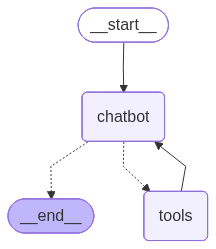

In [14]:

graph_builder = StateGraph(State)
graph_builder.add_node('chatbot', chatbot)
graph_builder.add_node('tools', ToolNode(tools=all_tools))
graph_builder.add_conditional_edges('chatbot', tools_condition, 'tools')
graph_builder.add_edge('tools', 'chatbot')
graph_builder.add_edge(START, 'chatbot')

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
config = {"configurable": {"thread_id": "10"}}

async def chat(user_input: str, history):
    result = await graph.ainvoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content

# Ensure we're using default asyncio event loop policy (set in cell 8)
# This prevents uvloop from causing issues when Gradio launches uvicorn in threads
import asyncio
asyncio.set_event_loop_policy(asyncio.DefaultEventLoopPolicy())

gr.ChatInterface(chat, type="messages").launch()


Exception in thread Thread-8 (run):
Traceback (most recent call last):
  File "/Users/samarthrao/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/Users/samarthrao/Documents/AIML EB udemy projects/agents/.venv/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "/Users/samarthrao/.local/share/uv/python/cpython-3.12.12-macos-aarch64-none/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/samarthrao/Documents/AIML EB udemy projects/agents/.venv/lib/python3.12/site-packages/uvicorn/server.py", line 66, in run
    return asyncio.run(self.serve(sockets=sockets))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/samarthrao/Documents/AIML EB udemy projects/agents/.venv/lib/python3.12/site-packages/nest_asyncio.py", line 26, in run
    loop = asyncio.get_event_loop

KeyboardInterrupt: 